## **2 - Data Understanding (EDA)**
---

In [1]:
import yaml
import joblib
import numpy as np
import pandas as pd

# Need to be installed.
import seaborn as sns
import scipy.stats as scs
import matplotlib.pyplot as plt

In [2]:
def load_config(path_config):
    """
    Load the configuration file (config.yaml).

    Parameters:
    ----------
    path_config : str
        Configuration file location.

    Returns:
    -------
    params : dict
        The configuration parameters.
    """

    # Try to load config.yaml file.
    try:
        with open(path_config, 'r') as file:
            params = yaml.safe_load(file)
    except FileNotFoundError as err:
        raise RuntimeError(f"Configuration file not found in {path_config}")

    return params

In [3]:
PATH_CONFIG = "../config/config.yaml"
config = load_config(PATH_CONFIG)

In [4]:
config

{'columns_object': ['stasiun', 'critical', 'category'],
 'datetime_columns': ['tanggal'],
 'features': ['stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2'],
 'int32_columns': ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max'],
 'label': 'category',
 'label_categories': ['BAIK', 'SEDANG', 'TIDAK SEHAT'],
 'label_categories_new': ['BAIK', 'TIDAK BAIK'],
 'object_columns': ['stasiun', 'critical', 'category'],
 'path_joined_data': '../data/interim/joined_dataset.pkl',
 'path_raw_data': '../data/raw/',
 'path_test_set': ['../data/interim/X_test.pkl', '../data/interim/y_test.pkl'],
 'path_train_set': ['../data/interim/X_train.pkl',
  '../data/interim/y_train.pkl'],
 'path_valid_set': ['../data/interim/X_valid.pkl',
  '../data/interim/y_valid.pkl'],
 'path_validated_data': '../data/interim/validated_data.pkl',
 'range_co': [-1, 47],
 'range_no2': [-1, 65],
 'range_o3': [-1, 151],
 'range_pm10': [-1, 179],
 'range_pm25': [-1, 174],
 'range_so2': [-1, 82],
 'range_stasiun': ['DKI1 (Bunderan HI)

## **Load Data**
---

In [5]:
X_train = joblib.load(config["path_train_set"][0])
y_train = joblib.load(config["path_train_set"][1])

In [6]:
dataset = pd.concat(
    [X_train, y_train],
    axis = 1
)

In [7]:
dataset

,stasiun,pm10,pm25,so2,co,o3,no2,category
947,DKI2 (Kelapa Gading),60,84,29,23,51,27,SEDANG
1041,DKI5 (Kebon Jeruk) Jakarta Barat,45,67,27,12,11,22,SEDANG
1389,DKI1 (Bunderan HI),74,100,27,15,24,24,SEDANG
31,DKI2 (Kelapa Gading),33,50,39,7,47,15,BAIK
1471,DKI4 (Lubang Buaya),87,156,42,11,30,25,TIDAK SEHAT
...,...,...,...,...,...,...,...,...
977,DKI3 (Jagakarsa),54,80,27,17,34,18,SEDANG
1282,DKI3 (Jagakarsa),56,86,45,9,39,13,SEDANG
403,DKI4 (Lubang Buaya),63,-1,25,21,38,7,SEDANG
35,DKI2 (Kelapa Gading),26,31,37,-1,54,12,SEDANG


## **3 - Exploratory Data Analysis**
---

## **3.1. Missing Value Check**
---

In [8]:
dataset = dataset.replace(-1, np.nan)

In [9]:
dataset.isnull().sum()

stasiun      0
pm10        44
pm25        73
so2         81
co          11
o3          38
no2         15
category     0
dtype: int64

## **3.2. Skewness Check**
---

In [10]:
dataset.skew(numeric_only=True)

pm10    0.209847
pm25    0.331529
so2     0.170298
co      2.002950
o3      1.283784
no2     0.908494
dtype: float64

## **3.3. Data Split**
---

In [11]:
dataset_baik = dataset[dataset["category"] == "BAIK"].copy()
dataset_tidak_baik = dataset[dataset["category"] != "BAIK"].copy()

In [12]:
dataset_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,143.000000,110.000000,149.000000,152.000000,149.000000,143.000000
mean,29.034965,40.263636,25.838926,8.815789,26.013423,11.573427
std,7.905616,8.255859,10.889536,4.032026,11.436066,6.633769
min,15.000000,13.000000,3.000000,2.000000,7.000000,3.000000
25%,24.000000,35.000000,18.000000,6.750000,16.000000,7.000000
50%,28.000000,41.000000,23.000000,8.000000,24.000000,10.000000
75%,33.000000,47.000000,36.000000,11.000000,36.000000,15.000000
max,50.000000,50.000000,50.000000,26.000000,49.000000,49.000000


In [13]:
dataset_tidak_baik.describe()

,pm10,pm25,so2,co,o3,no2
count,1263.000000,1267.000000,1220.000000,1287.000000,1263.000000,1292.000000
mean,55.513064,82.808998,36.505738,11.972028,32.590657,19.998452
std,13.356965,22.254484,12.211392,5.032321,14.466020,8.754505
min,19.000000,19.000000,2.000000,3.000000,9.000000,1.000000
25%,48.000000,67.000000,27.000000,9.000000,23.000000,14.000000
50%,56.000000,81.000000,37.000000,11.000000,29.000000,18.000000
75%,63.000000,96.000000,45.000000,14.000000,39.000000,25.000000
max,179.000000,174.000000,82.000000,47.000000,134.000000,65.000000


## **3.4. Visualization**
---

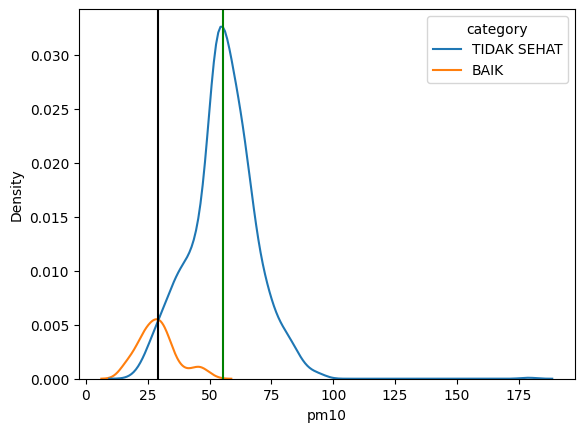

In [14]:
# pm10 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "pm10",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["pm10"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["pm10"].mean(), 0, 1, color='k')
plt.show()

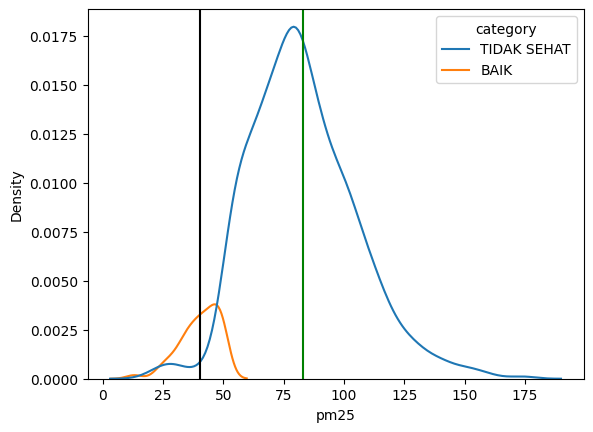

In [15]:
# pm25 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "pm25",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["pm25"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["pm25"].mean(), 0, 1, color='k')
plt.show()

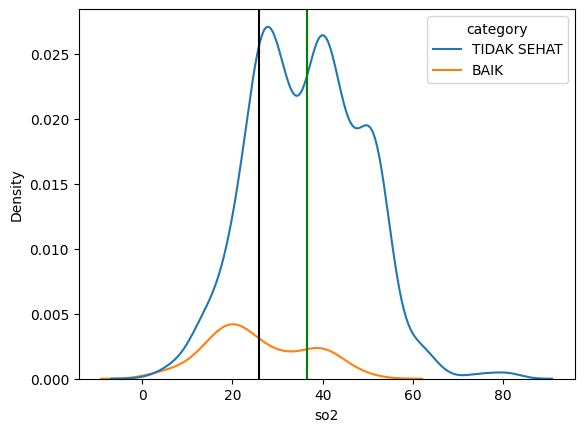

In [16]:
# so2 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "so2",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["so2"].mean(), 0, 1, color='g')
plt.axvline(dataset_baik["so2"].mean(), 0, 1, color='k')
plt.show()

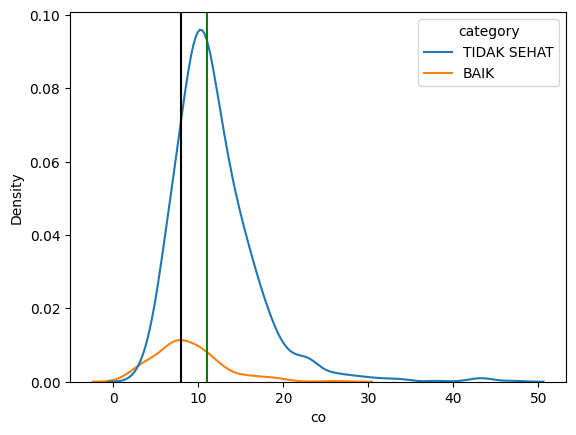

In [17]:
# co column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "co",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["co"].median(), 0, 1, color='g')
plt.axvline(dataset_baik["co"].median(), 0, 1, color='k')
plt.show()

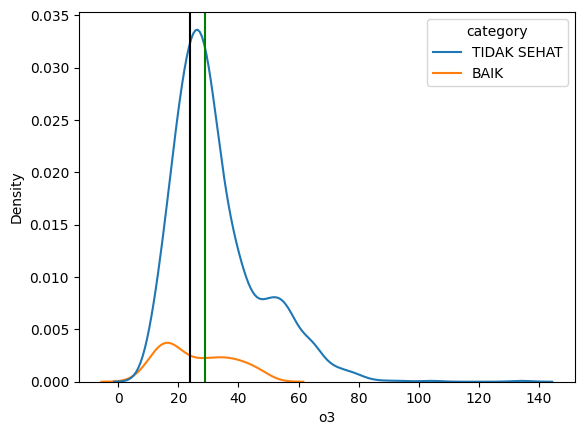

In [18]:
# o3 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "o3",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["o3"].median(), 0, 1, color='g')
plt.axvline(dataset_baik["o3"].median(), 0, 1, color='k')
plt.show()

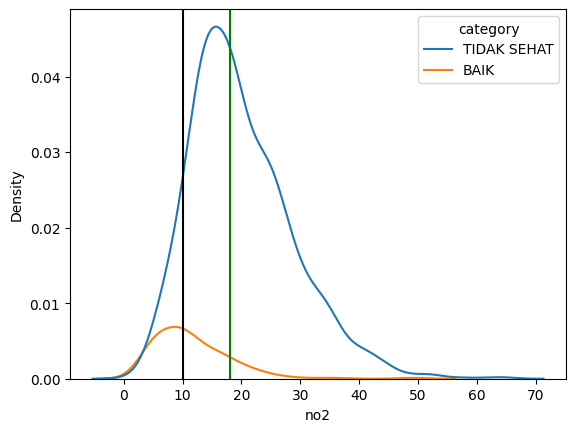

In [19]:
# no2 column distribution.
sns.kdeplot(
    data = dataset.replace("SEDANG", "TIDAK SEHAT"),
    x = "no2",
    hue = "category"
)
plt.axvline(dataset_tidak_baik["no2"].median(), 0, 1, color='g')
plt.axvline(dataset_baik["no2"].median(), 0, 1, color='k')
plt.show()

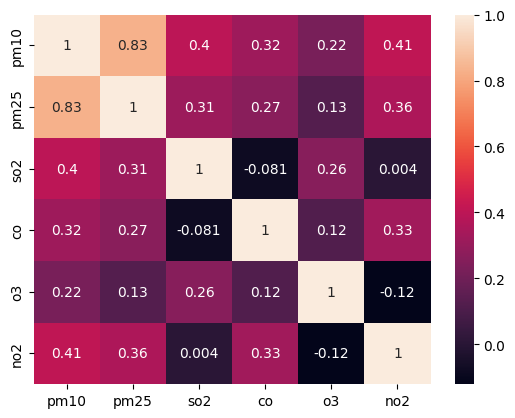

In [20]:
# Pearson Correlation.
sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True
)
plt.show()

## **3.5. Hypothesis Test**
---

In [21]:
# pm10 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["pm10"].isnull() != True].pm10,
    dataset_tidak_baik[dataset_tidak_baik["pm10"].isnull() != True].pm10
)

TtestResult(statistic=np.float64(-23.244221339711885), pvalue=np.float64(2.2197500856466876e-101), df=np.float64(1404.0))

In [22]:
# t-critical for alpha=0.05 and dof=n-2
scs.t.ppf(0.05, df=(len(dataset) - 2))

np.float64(-1.6459066313849768)

In [23]:
# pm25 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["pm25"].isnull() != True].pm25,
    dataset_tidak_baik[dataset_tidak_baik["pm25"].isnull() != True].pm25
)

TtestResult(statistic=np.float64(-19.926407236483072), pvalue=np.float64(8.134613396667222e-78), df=np.float64(1375.0))

In [24]:
# so2 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["so2"].isnull() != True].so2,
    dataset_tidak_baik[dataset_tidak_baik["so2"].isnull() != True].so2
)

TtestResult(statistic=np.float64(-10.179096125413354), pvalue=np.float64(1.653288800918951e-23), df=np.float64(1367.0))

In [25]:
# co t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["co"].isnull() != True].co,
    dataset_tidak_baik[dataset_tidak_baik["co"].isnull() != True].co
)

TtestResult(statistic=np.float64(-7.454343783089523), pvalue=np.float64(1.5537752178737805e-13), df=np.float64(1437.0))

In [26]:
# o3 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["o3"].isnull() != True].o3,
    dataset_tidak_baik[dataset_tidak_baik["o3"].isnull() != True].o3
)

TtestResult(statistic=np.float64(-5.3554085327667185), pvalue=np.float64(9.955830297164867e-08), df=np.float64(1410.0))

In [27]:
# no2 t-value.
scs.ttest_ind(
    dataset_baik[dataset_baik["no2"].isnull() != True].no2,
    dataset_tidak_baik[dataset_tidak_baik["no2"].isnull() != True].no2
)

TtestResult(statistic=np.float64(-11.157689468794274), pvalue=np.float64(8.827735493686356e-28), df=np.float64(1433.0))

## **3.6. Imbalanced Label Check**
---

In [28]:
dataset["category"].value_counts(normalize=True)

category
SEDANG         0.719310
TIDAK SEHAT    0.175862
BAIK           0.104828
Name: proportion, dtype: float64

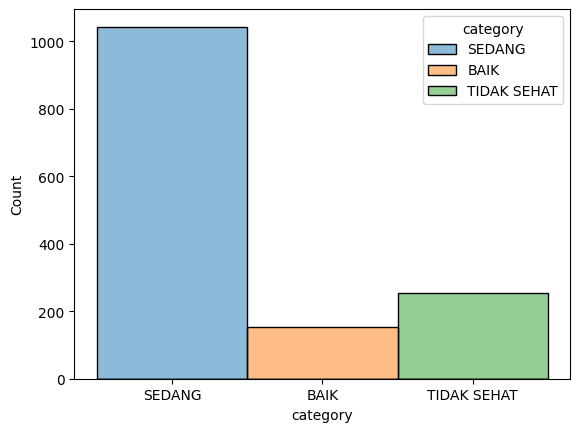

In [29]:
sns.histplot(
    data = dataset,
    x = "category",
    hue="category"
)
plt.show()

## **3.7. Outliers Check**
---

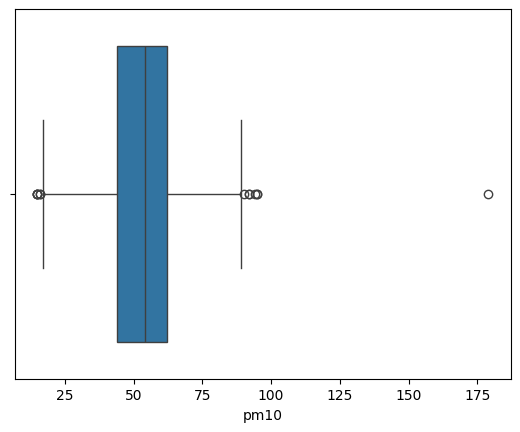

In [30]:
# pm10 boxplot.
sns.boxplot(
    data = dataset,
    x = "pm10"
)
plt.show()

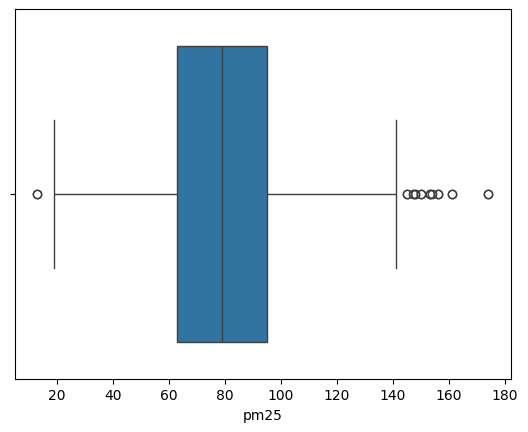

In [31]:
# pm25 boxplot.
sns.boxplot(
    data = dataset,
    x = "pm25"
)
plt.show()

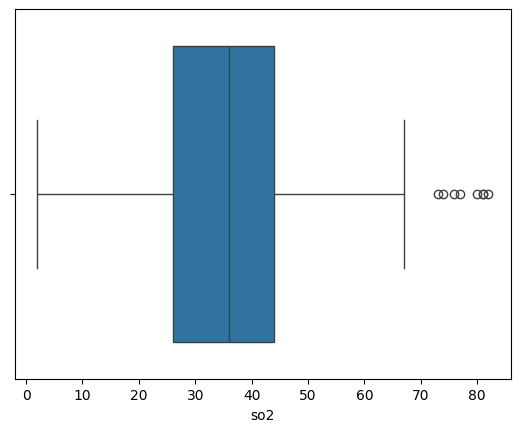

In [32]:
# so2 boxplot.
sns.boxplot(
    data = dataset,
    x = "so2"
)
plt.show()

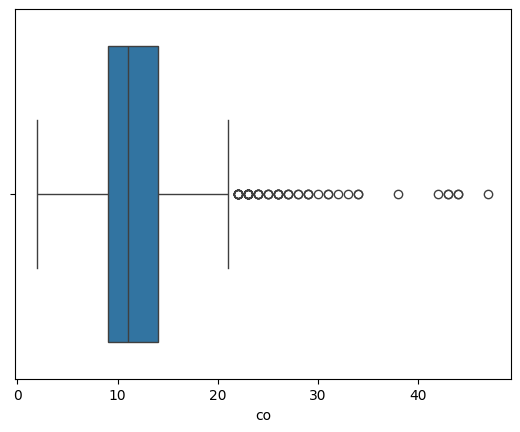

In [33]:
# co boxplot.
sns.boxplot(
    data = dataset,
    x = "co"
)
plt.show()

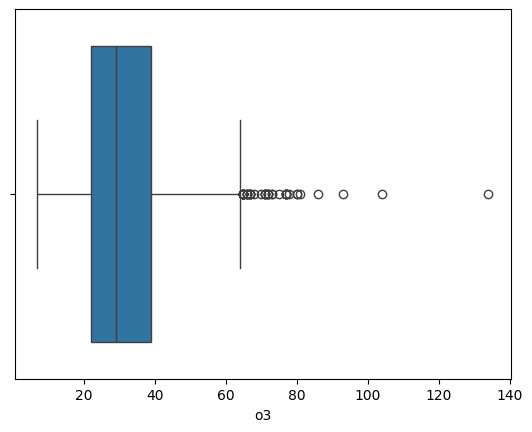

In [34]:
# o3 boxplot.
sns.boxplot(
    data = dataset,
    x = "o3"
)
plt.show()

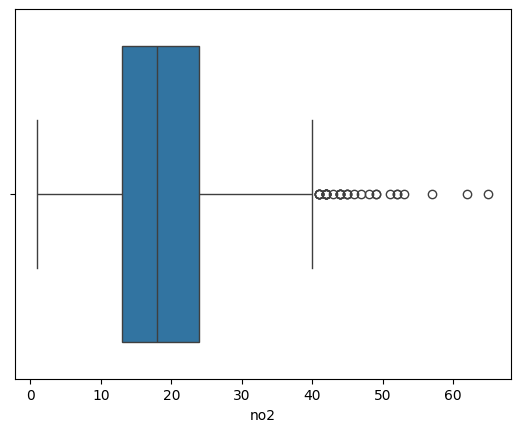

In [35]:
# no2 boxplot.
sns.boxplot(
    data = dataset,
    x = "no2"
)
plt.show()